In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

In [14]:
df = pd.read_excel('C:\\Users\\ilias\\Documents\\Howest\\Orac\\EnergieAnalyse\\EV\\data\\energie_orac_2024.xlsx')

In [15]:
df.head()

,datetime,afname_kwh,injectie_kwh,productie_kwh
0,2024-01-01 00:00:00,10.625,0.0,0.0
1,2024-01-01 00:15:00,10.625,0.0,0.0
2,2024-01-01 00:30:00,11.875,0.0,0.0
3,2024-01-01 00:45:00,13.750,0.0,0.0
4,2024-01-01 01:00:00,14.375,0.0,0.0


In [17]:
df['totaal_verbruik_kwh'] = df['afname_kwh'] + df['productie_kwh'] - df['injectie_kwh']

In [18]:
# Maak kopieën van kolommen in PU
df['Verbruik_pu'] = df['totaal_verbruik_kwh'] / df['totaal_verbruik_kwh'].sum()
df['Injectie_pu'] = df['injectie_kwh'] / df['injectie_kwh'].sum()
df['Productie_pu'] = df['productie_kwh'] / df['productie_kwh'].sum()



In [19]:
# Eigen verbruik PU
df["Verschil"] = df["Productie_pu"] - df["Verbruik_pu"]

df.head()


,datetime,afname_kwh,injectie_kwh,productie_kwh,totaal_verbruik_kwh,Verbruik_pu,Injectie_pu,Productie_pu,Verschil
0,2024-01-01 00:00:00,10.625,0.0,0.0,10.625,0.000005,0.0,0.0,-0.000005
1,2024-01-01 00:15:00,10.625,0.0,0.0,10.625,0.000005,0.0,0.0,-0.000005
2,2024-01-01 00:30:00,11.875,0.0,0.0,11.875,0.000005,0.0,0.0,-0.000005
3,2024-01-01 00:45:00,13.750,0.0,0.0,13.750,0.000006,0.0,0.0,-0.000006
4,2024-01-01 01:00:00,14.375,0.0,0.0,14.375,0.000006,0.0,0.0,-0.000006


In [20]:
df['Eigenverbruik'] = np.where(df['Verschil'] < 0, 
                               df['Productie_pu'], 
                               df['Verbruik_pu'])

# Resultaat bekijken
df.head()

,datetime,afname_kwh,injectie_kwh,productie_kwh,totaal_verbruik_kwh,Verbruik_pu,Injectie_pu,Productie_pu,Verschil,Eigenverbruik
0,2024-01-01 00:00:00,10.625,0.0,0.0,10.625,0.000005,0.0,0.0,-0.000005,0.0
1,2024-01-01 00:15:00,10.625,0.0,0.0,10.625,0.000005,0.0,0.0,-0.000005,0.0
2,2024-01-01 00:30:00,11.875,0.0,0.0,11.875,0.000005,0.0,0.0,-0.000005,0.0
3,2024-01-01 00:45:00,13.750,0.0,0.0,13.750,0.000006,0.0,0.0,-0.000006,0.0
4,2024-01-01 01:00:00,14.375,0.0,0.0,14.375,0.000006,0.0,0.0,-0.000006,0.0


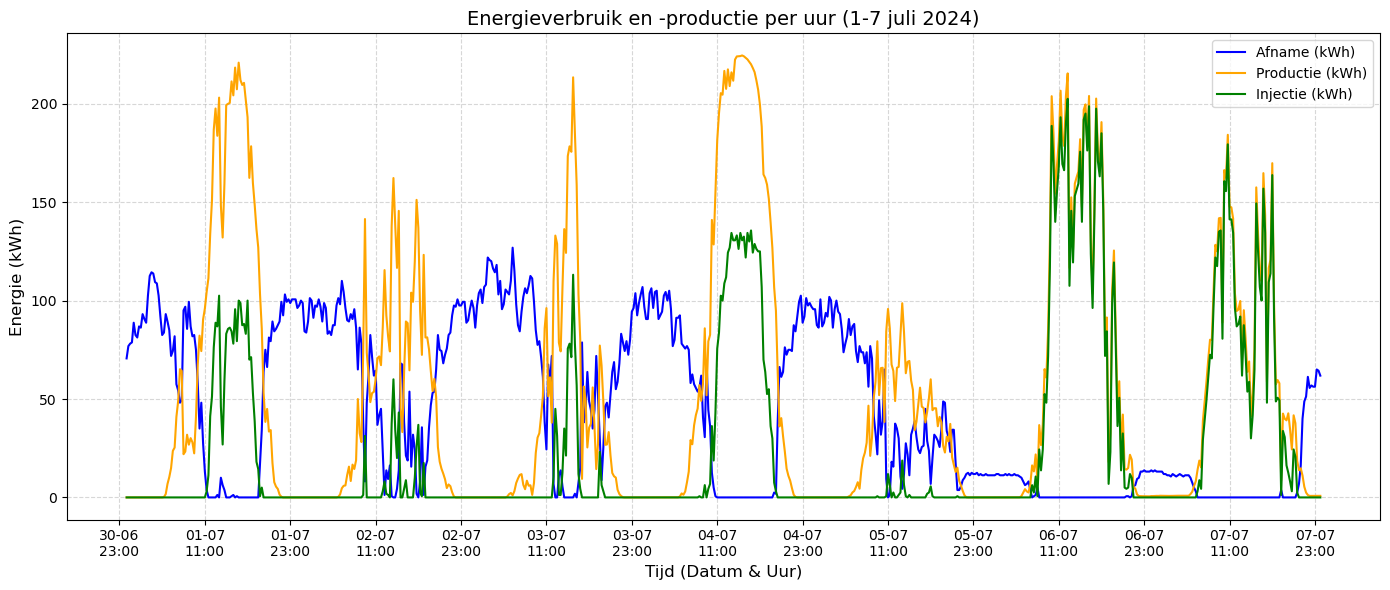

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  # <-- Belangrijke toevoeging voor datums en uren

# Filter data voor een specifieke week (bijv. 1-7 juli) uur per uur
start_date = '2024-07-01'
end_date = '2024-07-07 23:59:59' # Zorg dat de hele laatste dag wordt meegenomen
mask = (df['datetime'] >= start_date) & (df['datetime'] <= end_date)
week_data = df.loc[mask]

# Plotten
plt.figure(figsize=(14, 6)) # Iets breder gemaakt zodat de uren perfect passen
plt.plot(week_data['datetime'], week_data['afname_kwh'], label='Afname (kWh)', color='blue')
plt.plot(week_data['datetime'], week_data['productie_kwh'], label='Productie (kWh)', color='orange')
plt.plot(week_data['datetime'], week_data['injectie_kwh'], label='Injectie (kWh)', color='green')

# --- HIER WORDEN DE UREN INGESTELD ---
# Zet elke 12 uur een dikke streep/label (00:00 en 12:00)
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=12))

# Formatteer de tekst: Dag-Maand op regel 1, Uur:Minuut op regel 2 (\n)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m\n%H:%M'))
# ------------------------------------

plt.title('Energieverbruik en -productie per uur (1-7 juli 2024)', fontsize=14)
plt.xlabel('Tijd (Datum & Uur)', fontsize=12) # Extra komma gecorrigeerd
plt.ylabel('Energie (kWh)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

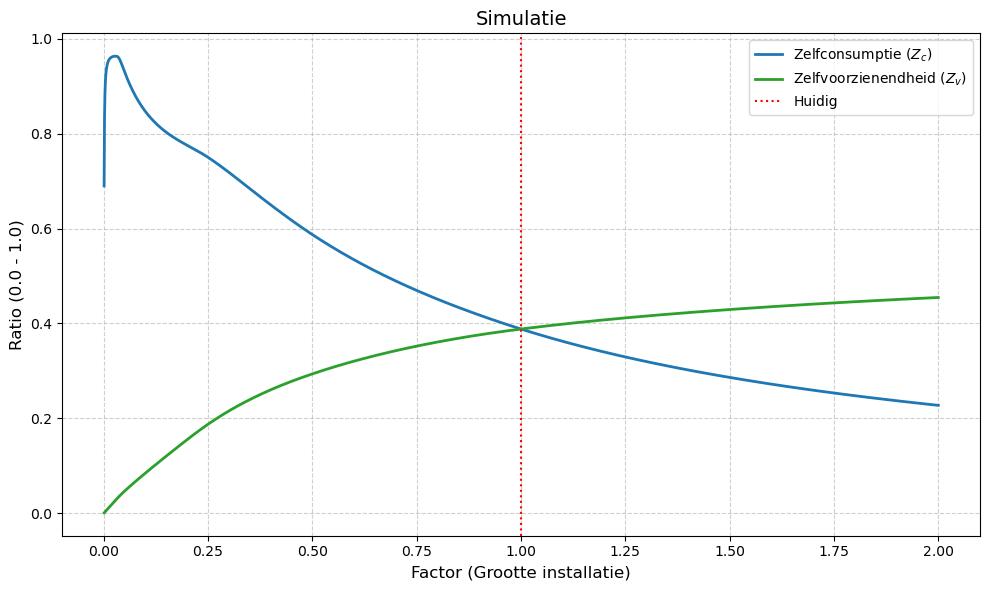

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Instellingen
factors = np.arange(0.001, 2.001, 0.001)

def bereken_simulatie(df, factors):
    zc_list = []
    zv_list = []
    total_verbruik = df['Verbruik_pu'].sum()
    
    for f in factors:
        sim_prod = df['Productie_pu'] * f
        # Eigenverbruik is het minimum van verbruik en gesimuleerde productie
        eigenverbruik = np.minimum(df['Verbruik_pu'], sim_prod)
        
        sum_ev = eigenverbruik.sum()
        sum_prod = sim_prod.sum()
        
        zc = sum_ev / sum_prod if sum_prod > 0 else 0
        zv = sum_ev / total_verbruik if total_verbruik > 0 else 0
        
        zc_list.append(zc)
        zv_list.append(zv)
    return zc_list, zv_list

# 2. Voer de berekeningen uit voor beide jaren
zc_2022, zv_2022 = bereken_simulatie(df, factors)

# 3. Plotten
fig, ax1 = plt.subplots(figsize=(10, 6))

# Grafiek voor 2022
ax1.plot(factors, zc_2022, label='Zelfconsumptie ($Z_c$)', color='#1f77b4', linewidth=2)
ax1.plot(factors, zv_2022, label='Zelfvoorzienendheid ($Z_v$)', color='#2ca02c', linewidth=2)
ax1.set_title('Simulatie', fontsize=14)
ax1.set_xlabel('Factor (Grootte installatie)', fontsize=12)
ax1.set_ylabel('Ratio (0.0 - 1.0)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.axvline(x=1.0, color='red', linestyle=':', label='Huidig')
ax1.legend()

plt.tight_layout()
plt.show()

Analyse voor 2023:
Aantal punten in eigenverbruik: 2000
Aantal punten in 1e afgeleide: 1999
Aantal punten in 2e afgeleide: 1998

Zone grenzen:
🟢 Groene zone (ideaal): factor 0.00 - 0.45
🟡 Gele zone (kan nog): factor 0.45 - 0.80
🔴 Rode zone (weinig winst): factor 0.80 - 2.00


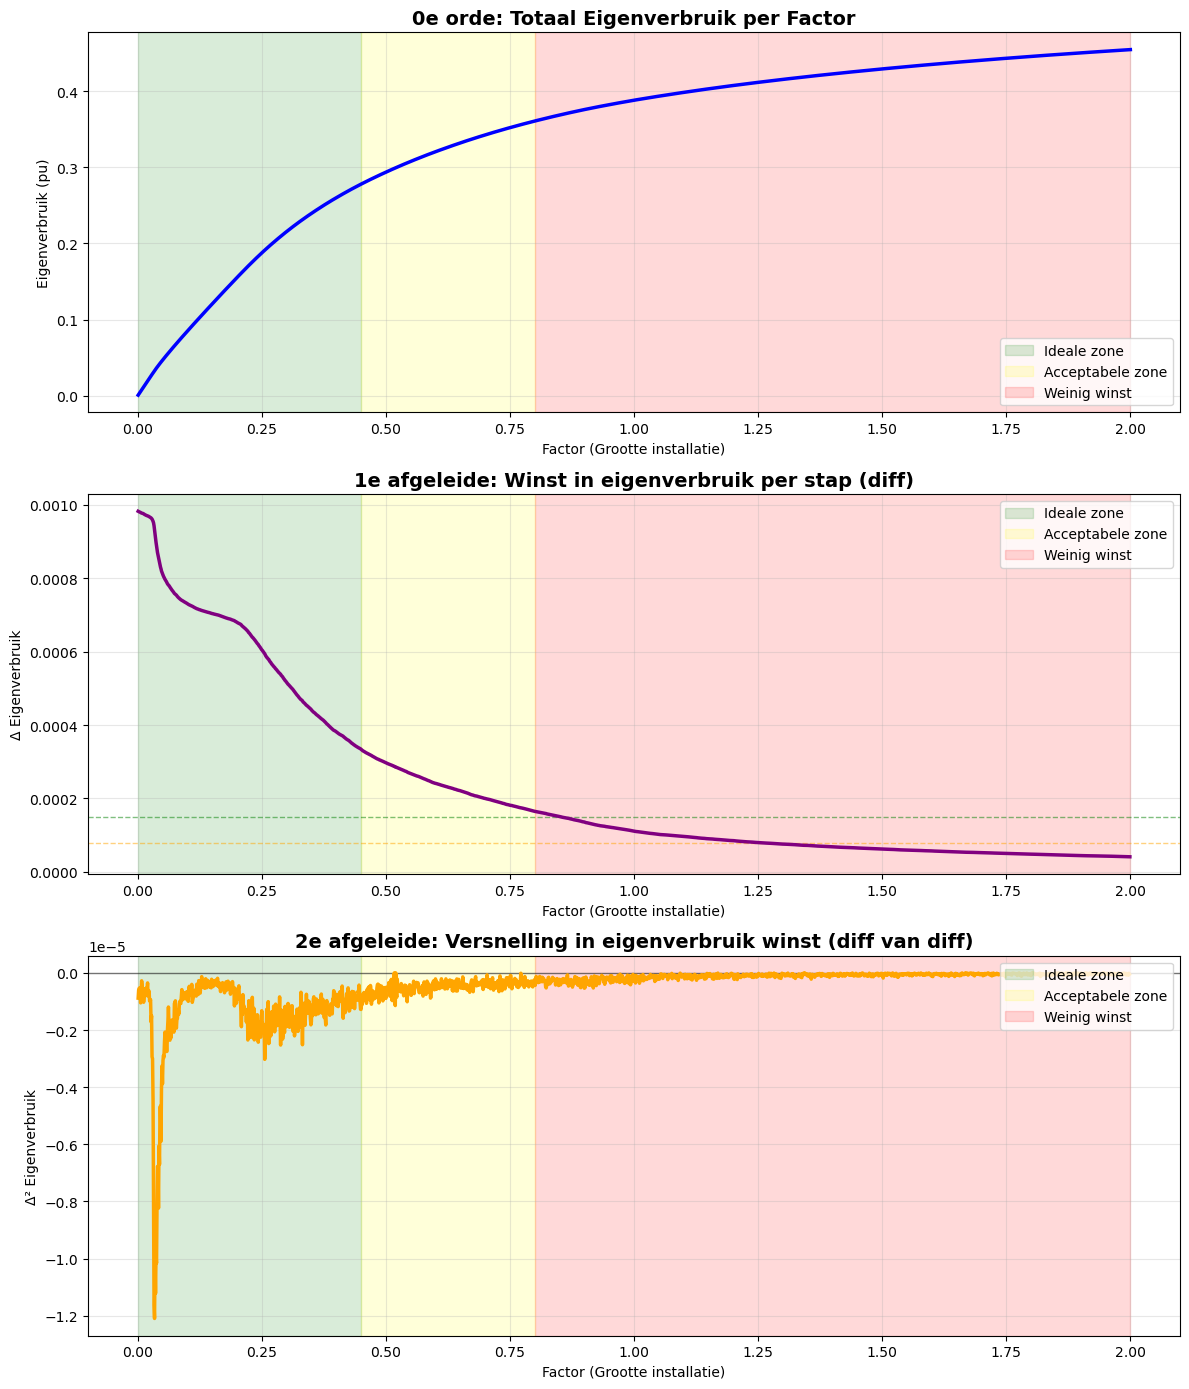

In [24]:
# --- Analyse met diff op Eigenverbruik: 0e, 1e en 2e afgeleide met zones ---

def bereken_eigenverbruik_en_afgeleiden(df, factors):
    """
    Berekent eigenverbruik en de 1e en 2e afgeleide met np.diff()
    """
    eigenverbruik_list = []
    
    # Bereken eigenverbruik voor elke factor
    for f in factors:
        sim_prod = df['Productie_pu'] * f
        eigenverbruik = np.minimum(df['Verbruik_pu'], sim_prod)
        eigenverbruik_list.append(eigenverbruik.sum())
    
    # Eerste afgeleide: hoeveel extra eigenverbruik per stap
    diff_1 = np.diff(eigenverbruik_list)
    
    # Tweede afgeleide: verandering in de winst per stap
    diff_2 = np.diff(diff_1)
    
    return eigenverbruik_list, diff_1, diff_2

# Bereken voor 2023
ev_list, diff_1, diff_2 = bereken_eigenverbruik_en_afgeleiden(df, factors)

# Definieer zones op basis van 1e afgeleide
# Vind waar de 1e afgeleide onder bepaalde drempels komt
factors_diff1 = factors[:-1]

# Drempels voor zones
drempel_groen_geel = 0.00015  # Grens tussen groen en geel
drempel_geel_rood = 0.00008   # Grens tussen geel en rood

# Vind de factor-waarden voor zone grenzen
idx_groen_geel = np.where(diff_1 < drempel_groen_geel)[0]
idx_geel_rood = np.where(diff_1 < drempel_geel_rood)[0]

# Stel zones in op basis van gebruikervoorkeur
grens_groen_geel = 0.45  # Grens tussen groen en geel (gewijzigd)
grens_geel_rood = 0.80   # Grens tussen geel en rood (gewijzigd)

print(f"Analyse voor 2023:")
print(f"Aantal punten in eigenverbruik: {len(ev_list)}")
print(f"Aantal punten in 1e afgeleide: {len(diff_1)}")
print(f"Aantal punten in 2e afgeleide: {len(diff_2)}")
print(f"\nZone grenzen:")
print(f"🟢 Groene zone (ideaal): factor 0.00 - {grens_groen_geel:.2f}")
print(f"🟡 Gele zone (kan nog): factor {grens_groen_geel:.2f} - {grens_geel_rood:.2f}")
print(f"🔴 Rode zone (weinig winst): factor {grens_geel_rood:.2f} - {factors[-1]:.2f}")

# Visualiseer de drie plots met gekleurde zones
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14))

# Functie om zones toe te voegen aan elke plot
def voeg_zones_toe(ax, y_min, y_max):
    ax.axvspan(0, grens_groen_geel, alpha=0.15, color='green', label='Ideale zone')
    ax.axvspan(grens_groen_geel, grens_geel_rood, alpha=0.15, color='yellow', label='Acceptabele zone')
    ax.axvspan(grens_geel_rood, factors[-1], alpha=0.15, color='red', label='Weinig winst')

# Plot 1: Eigenverbruik vs Factor
voeg_zones_toe(ax1, 0, max(ev_list))
ax1.plot(factors, ev_list, color='blue', linewidth=2.5, zorder=3)
ax1.set_title('0e orde: Totaal Eigenverbruik per Factor', fontsize=14, fontweight='bold')
ax1.set_xlabel('Factor (Grootte installatie)')
ax1.set_ylabel('Eigenverbruik (pu)')
ax1.grid(True, alpha=0.3, zorder=1)
ax1.legend(loc='lower right')

# Plot 2: Eerste afgeleide (diff)
voeg_zones_toe(ax2, min(diff_1), max(diff_1))
ax2.plot(factors_diff1, diff_1, color='purple', linewidth=2.5, zorder=3)
ax2.axhline(y=drempel_groen_geel, color='green', linestyle='--', alpha=0.5, linewidth=1)
ax2.axhline(y=drempel_geel_rood, color='orange', linestyle='--', alpha=0.5, linewidth=1)
ax2.set_title('1e afgeleide: Winst in eigenverbruik per stap (diff)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Factor (Grootte installatie)')
ax2.set_ylabel('Δ Eigenverbruik')
ax2.grid(True, alpha=0.3, zorder=1)
ax2.legend(loc='upper right')

# Plot 3: Tweede afgeleide (diff van diff)
factors_diff2 = factors[:-2]  # tweede diff heeft 2 elementen minder
voeg_zones_toe(ax3, min(diff_2), max(diff_2))
ax3.plot(factors_diff2, diff_2, color='orange', linewidth=2.5, zorder=3)
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
ax3.set_title('2e afgeleide: Versnelling in eigenverbruik winst (diff van diff)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Factor (Grootte installatie)')
ax3.set_ylabel('Δ² Eigenverbruik')
ax3.grid(True, alpha=0.3, zorder=1)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()


--- Scenario en uitgangspunten ---
Scenario: Huidig scenario (gemeten opbrengst + totaalverbruik 2023)
Installatiefactor: 1.000
Jaarverbruik: 2,351,504.5 kWh = 2,351.505 MWh
Jaarproductie: 1,221,227.3 kWh
Sweep: 0 -> 2 kWh/MWh, stap 0.001 (2001 punten)
Cycli-limiet op basis van batterijkeuze: 500.0 cycli/jaar


,ratio_kWh_per_MWh,battery_nominal_kWh,Z_c,Z_v,equivalent_cycles_per_year,cycles_ok
0,0.0,0.000000,0.576817,0.299563,0.000000,True
100,0.1,235.150452,0.621517,0.322778,268.685903,True
200,0.2,470.300903,0.656820,0.341112,240.443883,True
500,0.5,1175.752259,0.718343,0.373064,170.139232,True
1000,1.0,2351.504517,0.772261,0.401065,117.478837,True
2000,2.0,4703.009034,0.831439,0.431798,76.524769,True


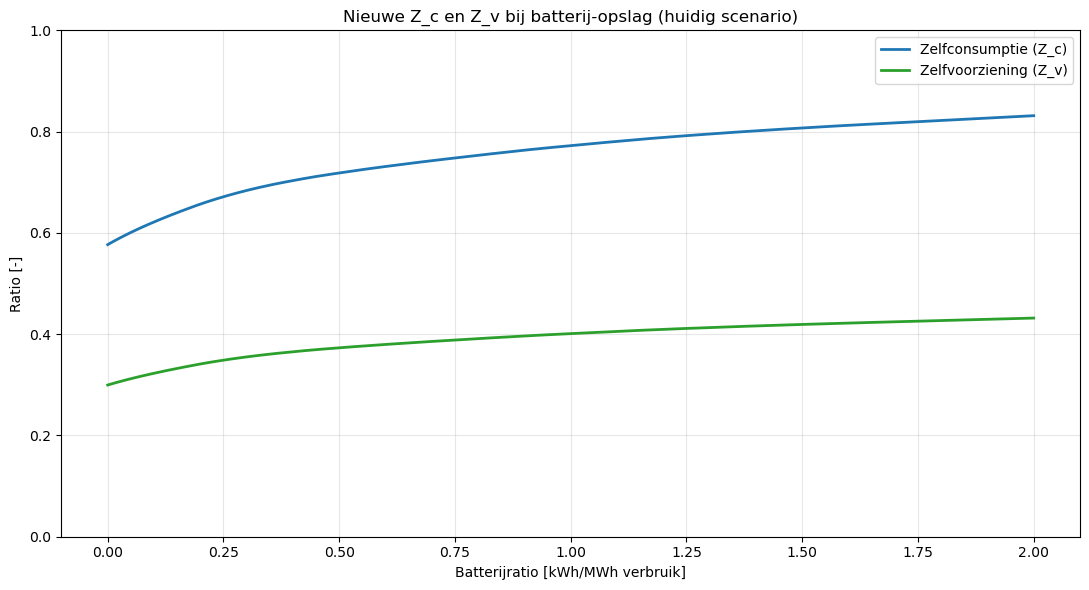

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================
# OPDRACHT 2 - Batterij op 1 gekozen scenario uit opdracht 1
# Gekozen scenario: huidig (zoals gemeten in Excel/CSV)
# 1 specifiek gedimensioneerde installatie: huidige installatie (factor = 1.0)
# Batterijratio: 0 -> 2 kWh/MWh verbruik, stap 0.001
# ==============================================================

# --- 0) Scenario kiezen en inputdata uit huidige dataset ---
scenario_naam = "Huidig scenario (gemeten opbrengst + totaalverbruik 2023)"
installatie_factor = 1.0  # 1 specifiek gedimensioneerde installatie

df_s = df.copy()

# AANPASSING 1: Kleine letter 'd' voor 'datetime'
if "datetime" in df_s.columns:
    df_s["datetime"] = pd.to_datetime(df_s["datetime"])
    df_s = df_s.sort_values("datetime").set_index("datetime")
elif not isinstance(df_s.index, pd.DatetimeIndex):
    df_s.index = pd.to_datetime(df_s.index)
    df_s = df_s.sort_index()

# Zorg dat totaalverbruik beschikbaar is (gebaseerd op jouw kolomnaam)
if "Totaalverbruik" not in df_s.columns:
    if "totaal_verbruik_kwh" in df_s.columns:
        df_s["Totaalverbruik"] = df_s["totaal_verbruik_kwh"]
    else:
        df_s["Totaalverbruik"] = df_s["afname_kwh"] + df_s["productie_kwh"] - df_s["injectie_kwh"]

# Tijdstap in uren (voor kwartierdata zal dit netjes uitkomen op 0.25 uur)
stap_uur = df_s.index.to_series().diff().dt.total_seconds().dropna().median() / 3600
if pd.isna(stap_uur) or stap_uur <= 0:
    raise ValueError("Kon geen geldige tijdstap (uur) bepalen uit de datetime-index.")

# AANPASSING 2: Verwijder '* stap_uur' bij load_kwh and prod_kwh omdat brondata al in kWh staat.
load_kwh = df_s["Totaalverbruik"].clip(lower=0).to_numpy()
prod_kwh = (df_s["productie_kwh"].clip(lower=0).to_numpy() * installatie_factor)

jaarverbruik_kwh = float(load_kwh.sum())
jaarverbruik_mwh = jaarverbruik_kwh / 1000.0  # expliciet kWh -> MWh
jaarproductie_kwh = float(prod_kwh.sum())

# --- 1) Batterijbank (pas aan naar de gekozen batterijbank) ---
batterij = {
    "dod": 0.90,
    "eta_charge": 0.96,
    "eta_discharge": 0.96,
    "self_discharge_per_day": 0.0005,
    "c_rate_charge": 0.5,       # Bepaalt het laadvermogen (0.5C betekent: laadt op in 2 uur)
    "c_rate_discharge": 0.5,    # Bepaalt het ontlaadvermogen
    "cycle_life_total": 6000,
    "target_lifetime_years": 12
}

max_cycles_per_year = batterij["cycle_life_total"] / batterij["target_lifetime_years"]
zelfontlading_stap = batterij["self_discharge_per_day"] * (stap_uur / 24.0)
# OPMERKING: De 'max_laadvermogen_stroom_kw' regel is hier succesvol verwijderd om KeyErrors te voorkomen.

# --- 2) Simulatie met minimale technische beperkingen ---
def simuleer_batterij(cap_nom_kwh):
    # Ratio 0 = geen opslag
    if cap_nom_kwh <= 0:
        direct = np.minimum(prod_kwh, load_kwh).sum()
        return {
            "Z_v": direct / jaarverbruik_kwh if jaarverbruik_kwh > 0 else 0.0,
            "Z_c": direct / jaarproductie_kwh if jaarproductie_kwh > 0 else 0.0,
            "eq_cycles": 0.0,
            "cycles_ok": True
        }

    dod = batterij["dod"]
    eta_c = batterij["eta_charge"]
    eta_d = batterij["eta_discharge"]

    bruikbaar_kwh = cap_nom_kwh * dod
    soc_min = cap_nom_kwh - bruikbaar_kwh
    soc_max = cap_nom_kwh
    soc = soc_min + 0.5 * bruikbaar_kwh

    # Laad- en ontlaadvermogen schalen nu correct en onbegrensd mee met de batterijcapaciteit
    p_laad_limiet_kw = batterij["c_rate_charge"] * cap_nom_kwh
    p_ontlaad_limiet_kw = batterij["c_rate_discharge"] * cap_nom_kwh

    e_laad_limiet = p_laad_limiet_kw * stap_uur
    e_ontlaad_limiet = p_ontlaad_limiet_kw * stap_uur

    direct_totaal = 0.0
    batterij_naar_last = 0.0
    ontladen_uit_soc = 0.0

    for p, l in zip(prod_kwh, load_kwh):
        # zelfontlading
        soc *= (1 - zelfontlading_stap)
        soc = max(min(soc, soc_max), soc_min)

        direct = min(p, l)
        direct_totaal += direct

        surplus = p - direct
        tekort = l - direct

        # Laden (beperkt door DoD-venster en C-rate)
        if surplus > 0:
            ruimte = soc_max - soc
            e_in = min(surplus, e_laad_limiet, ruimte / eta_c if eta_c > 0 else 0)
            soc += e_in * eta_c

        # Ontladen (beperkt door DoD-venster en C-rate)
        if tekort > 0:
            e_out = min(tekort, e_ontlaad_limiet, (soc - soc_min) * eta_d if eta_d > 0 else 0)
            soc -= e_out / eta_d if eta_d > 0 else 0
            batterij_naar_last += e_out
            ontladen_uit_soc += e_out / eta_d if eta_d > 0 else 0

    z_v = (direct_totaal + batterij_naar_last) / jaarverbruik_kwh if jaarverbruik_kwh > 0 else 0.0
    z_c = (direct_totaal + batterij_naar_last) / jaarproductie_kwh if jaarproductie_kwh > 0 else 0.0
    eq_cycles = ontladen_uit_soc / bruikbaar_kwh if bruikbaar_kwh > 0 else 0.0

    return {
        "Z_v": z_v,
        "Z_c": z_c,
        "eq_cycles": eq_cycles,
        "cycles_ok": eq_cycles <= max_cycles_per_year
    }

# --- 3) Sweep 0 -> 2 kWh/MWh in stappen van 0.001 ---
ratios = np.round(np.arange(0.0, 2.0001, 0.001), 3)
records = []

for ratio in ratios:
    cap_nom_kwh = ratio * jaarverbruik_mwh
    sim = simuleer_batterij(cap_nom_kwh)

    records.append({
        "ratio_kWh_per_MWh": ratio,
        "battery_nominal_kWh": cap_nom_kwh,
        "Z_c": sim["Z_c"],
        "Z_v": sim["Z_v"],
        "equivalent_cycles_per_year": sim["eq_cycles"],
        "cycles_ok": sim["cycles_ok"]
    })

results_bat = pd.DataFrame(records)

# Referentiepunten aangepast met extra kleine stappen (0.1 en 0.2) voor beter inzicht
display_ratios = [0.0, 0.1, 0.2, 0.5, 1.0, 2.0]

print("--- Scenario en uitgangspunten ---")
print(f"Scenario: {scenario_naam}")
print(f"Installatiefactor: {installatie_factor:.3f}")
print(f"Jaarverbruik: {jaarverbruik_kwh:,.1f} kWh = {jaarverbruik_mwh:,.3f} MWh")
print(f"Jaarproductie: {jaarproductie_kwh:,.1f} kWh")
print(f"Sweep: 0 -> 2 kWh/MWh, stap 0.001 ({len(ratios)} punten)")
print(f"Cycli-limiet op basis van batterijkeuze: {max_cycles_per_year:.1f} cycli/jaar")

display(
    results_bat[results_bat["ratio_kWh_per_MWh"].isin(display_ratios)][[
        "ratio_kWh_per_MWh", "battery_nominal_kWh", "Z_c", "Z_v",
        "equivalent_cycles_per_year", "cycles_ok"
    ]]
)

# --- 4) Gevraagde grafiek: enkel Z_c en Z_v voor batterij ---
plt.figure(figsize=(11, 6))
plt.plot(results_bat["ratio_kWh_per_MWh"], results_bat["Z_c"], label="Zelfconsumptie (Z_c)", color="tab:blue", linewidth=2)
plt.plot(results_bat["ratio_kWh_per_MWh"], results_bat["Z_v"], label="Zelfvoorziening (Z_v)", color="tab:green", linewidth=2)

plt.xlabel("Batterijratio [kWh/MWh verbruik]")
plt.ylabel("Ratio [-]")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.title("Nieuwe Z_c en Z_v bij batterij-opslag (huidig scenario)")
plt.tight_layout()
plt.savefig("batterij_simulatie_output.png") # Sla de afbeelding netjes op
plt.show()

Max afwijking ratio-check: 5.863e-04
/1000 gebruik je alleen bij kWh -> MWh omzetting, niet nog eens op dezelfde ratio.
Z_c bij ratio 0.0: 57.68%
Z_c bij ratio 2.0: 83.14%
Max winst 1e afgeleide: 53.436170 %-punt per (kWh/MWh)

Zone-indeling:
🟢 Groen: 0.00 - 0.25
🟡 Geel: 0.25 - 0.50
🔴 Rood: 0.50 - 2.00


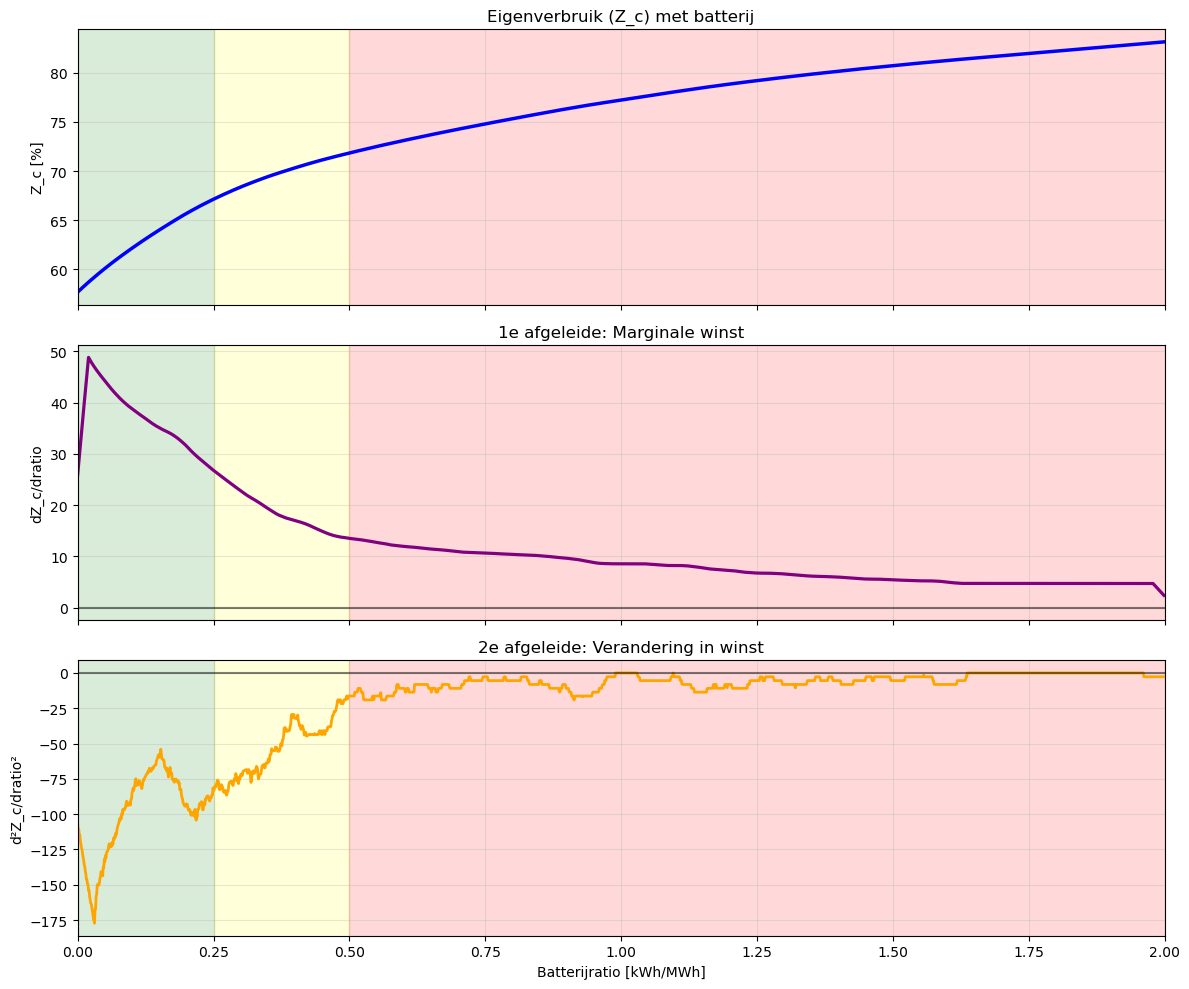

In [37]:
# =================================================================
# AFGELEIDE: Eigenverbruik (Z_c) met batterij
# =================================================================

# Zonendef inities
grens_groen_geel = 0.25  # Grens tussen groen en geel: 0-0.85 groen
grens_geel_rood = 0.5    # Grens tussen geel en rood: 0.85-1.5 geel, 1.5+ rood

# Z_c in %
eigenverbruik_pct = results_bat["Z_c"].to_numpy(dtype=float) * 100.0

# Ratio-as: al in kWh/MWh
ratios = results_bat["ratio_kWh_per_MWh"].to_numpy(dtype=float)

jaarverbruik_kwh = float(df_s["Totaalverbruik"].sum())

# Eenheidscheck (factor 1000 exact 1 keer)
# ratio [kWh/MWh] = cap[kWh] / jaarverbruik[kWh] * 1000
if "battery_nominal_kWh" in results_bat.columns:
    ratio_check = results_bat["battery_nominal_kWh"].to_numpy(dtype=float) / jaarverbruik_kwh * 1000.0
elif "battery_capacity_kWh" in results_bat.columns:
    ratio_check = results_bat["battery_capacity_kWh"].to_numpy(dtype=float) / jaarverbruik_kwh * 1000.0
else:
    ratio_check = ratios

print(f"Max afwijking ratio-check: {np.max(np.abs(ratios - ratio_check)):.3e}")
print("/1000 gebruik je alleen bij kWh -> MWh omzetting, niet nog eens op dezelfde ratio.")

# Afgeleiden met correcte as
ratios_diff1 = ratios[:-1]
ratios_diff2 = ratios[:-2]

diff_1 = np.diff(eigenverbruik_pct) / np.diff(ratios)          # dZc/dratio
diff_2 = np.diff(diff_1) / np.diff(ratios_diff1)              # d2Zc/dratio2

# Lichte smoothing voor stabielere 2e afgeleide
def smooth(y, window=41):
    if len(y) < 5:
        return y
    w = min(window, len(y) if len(y) % 2 == 1 else len(y) - 1)
    if w < 3:
        return y
    return np.convolve(y, np.ones(w) / w, mode="same")

diff_1_plot = smooth(diff_1, window=41)
diff_2_plot = smooth(diff_2, window=61)

print(f"Z_c bij ratio 0.0: {eigenverbruik_pct[0]:.2f}%")
print(f"Z_c bij ratio 2.0: {eigenverbruik_pct[-1]:.2f}%")
print(f"Max winst 1e afgeleide: {diff_1.max():.6f} %-punt per (kWh/MWh)")
print(f"\nZone-indeling:")
print(f"🟢 Groen: 0.00 - {grens_groen_geel:.2f}")
print(f"🟡 Geel: {grens_groen_geel:.2f} - {grens_geel_rood:.2f}")
print(f"🔴 Rood: {grens_geel_rood:.2f} - 2.00")

# Grafieken
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 0e orde
ax1.plot(ratios, eigenverbruik_pct, color="blue", linewidth=2.5)
ax1.axvspan(0, grens_groen_geel, alpha=0.15, color="green")
ax1.axvspan(grens_groen_geel, grens_geel_rood, alpha=0.15, color="yellow")
ax1.axvspan(grens_geel_rood, ratios[-1], alpha=0.15, color="red")
ax1.set_ylabel("Z_c [%]")
ax1.set_title("Eigenverbruik (Z_c) met batterij")
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, ratios[-1])

# 1e afgeleide
ax2.plot(ratios_diff1, diff_1_plot, color="purple", linewidth=2.3)
ax2.axhline(y=0, color="black", linestyle="-", alpha=0.5)
ax2.axvspan(0, grens_groen_geel, alpha=0.15, color="green")
ax2.axvspan(grens_groen_geel, grens_geel_rood, alpha=0.15, color="yellow")
ax2.axvspan(grens_geel_rood, ratios[-1], alpha=0.15, color="red")
ax2.set_ylabel("dZ_c/dratio")
ax2.set_title("1e afgeleide: Marginale winst")
ax2.grid(True, alpha=0.3)

# 2e afgeleide
ax3.plot(ratios_diff2, diff_2_plot, color="orange", linewidth=2.0)
ax3.axhline(y=0, color="black", linestyle="-", alpha=0.5)
ax3.axvspan(0, grens_groen_geel, alpha=0.15, color="green")
ax3.axvspan(grens_groen_geel, grens_geel_rood, alpha=0.15, color="yellow")
ax3.axvspan(grens_geel_rood, ratios[-1], alpha=0.15, color="red")
ax3.set_ylabel("d²Z_c/dratio²")
ax3.set_xlabel("Batterijratio [kWh/MWh]")
ax3.set_title("2e afgeleide: Verandering in winst")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# --- Haal de data direct uit je bestaande resultaten ---
gekozen_ratio = 0.25

# Zoek de nulmeting (zonder batterij) en de gekozen ratio op in je bestaande dataframe
rij_basis = results_bat[results_bat["ratio_kWh_per_MWh"] == 0.0].iloc[0]
rij_bat = results_bat[results_bat["ratio_kWh_per_MWh"] == gekozen_ratio].iloc[0]

# --- KPI Tabel opbouwen met de reeds berekende data ---
kpi_data = {
    "KPI Parameter": [
        "Gekozen Batterijratio",
        "Nominale Batterijcapaciteit",
        "Bruikbare Batterijcapaciteit (90% DoD)",
        "Zelfconsumptie (Z_c) zonder batterij",
        "Nieuwe Zelfconsumptie (Z_c) met batterij",
        "Winst in Zelfconsumptie (Delta Z_c)",
        "Zelfvoorziening (Z_v) zonder batterij",
        "Nieuwe Zelfvoorziening (Z_v) met batterij",
        "Winst in Zelfvoorziening (Delta Z_v)",
        "Equivalent aantal volledige cycli / jaar",
        "Voldoet aan levensduur-eis (max 500/jaar)?"
    ],
    "Waarde": [
        f"{rij_bat['ratio_kWh_per_MWh']:.3f} kWh/MWh",
        f"{rij_bat['battery_nominal_kWh']:,.1f} kWh",
        f"{(rij_bat['battery_nominal_kWh'] * 0.9):,.1f} kWh",
        f"{rij_basis['Z_c'] * 100:.2f}%",
        f"{rij_bat['Z_c'] * 100:.2f}%",
        f"{(rij_bat['Z_c'] - rij_basis['Z_c']) * 100:+.2f}%",
        f"{rij_basis['Z_v'] * 100:.2f}%",
        f"{rij_bat['Z_v'] * 100:.2f}%",
        f"{(rij_bat['Z_v'] - rij_basis['Z_v']) * 100:+.2f}%",
        f"{rij_bat['equivalent_cycles_per_year']:.1f} cycli/jaar",
        "JA (OK)" if rij_bat['cycles_ok'] else "NEE"
    ]
}

kpi_tabel = pd.DataFrame(kpi_data)

print(f"=======================================================")
print(f" KPI RAPPORT DIRECT UIT SIMULATIE (Ratio = {gekozen_ratio})")
print(f"=======================================================")
display(kpi_tabel)

 KPI RAPPORT DIRECT UIT SIMULATIE (Ratio = 0.25)


,KPI Parameter,Waarde
0,Gekozen Batterijratio,0.250 kWh/MWh
1,Nominale Batterijcapaciteit,587.9 kWh
2,Bruikbare Batterijcapaciteit (90% DoD),529.1 kWh
3,Zelfconsumptie (Z_c) zonder batterij,57.68%
4,Nieuwe Zelfconsumptie (Z_c) met batterij,67.14%
5,Winst in Zelfconsumptie (Delta Z_c),+9.45%
6,Zelfvoorziening (Z_v) zonder batterij,29.96%
7,Nieuwe Zelfvoorziening (Z_v) met batterij,34.87%
8,Winst in Zelfvoorziening (Delta Z_v),+4.91%
9,Equivalent aantal volledige cycli / jaar,227.3 cycli/jaar


In [40]:
# --- Financiële parameters aanpassen op basis van je contract ---
investering = 3 * 60000  # Totale hardware-investering: €180.000,-

# Bereken de spread: Inkoopprijs (incl. netkosten) minus injectievergoeding
# Vervang 0.13 door jouw werkelijke spread (bijv. 0.12 of 0.15)
financiele_factor_per_kwh = 0.13  

# --- ROI en Terugverdientijd berekenen ---
# 1. Bereken hoeveel kWh er netto door de batterij van het net is gehaald
bespaarde_kwh_per_jaar = (rij_bat['Z_v'] - rij_basis['Z_v']) * jaarverbruik_kwh

# 2. Vermenigvuldig de kWh's met de financiële spread
besparing_per_jaar = bespaarde_kwh_per_jaar * financiele_factor_per_kwh

# 3. ROI en TVT (met herstelde Python syntax)
roi = (besparing_per_jaar * 100) / investering if investering > 0 else 0.0
terugverdientijd = investering / besparing_per_jaar if besparing_per_jaar > 0 else float('inf')

# --- Resultaten printen ---
print(f"Verschoven energie: {bespaarde_kwh_per_jaar:,.0f} kWh/jaar")
print(f"Financiële besparing: €{besparing_per_jaar:,.2f} per jaar")
print(f"ROI: {roi:.2f}% per jaar")
print(f"Terugverdientijd: {terugverdientijd:.1f} jaar")

Verschoven energie: 115,428 kWh/jaar
Financiële besparing: €15,005.60 per jaar
ROI: 8.34% per jaar
Terugverdientijd: 12.0 jaar


In [41]:
# --- Financiële parameters voor 2 stuks ---
aantal_kasten = 2
prijs_per_kast = 60000
investering = aantal_kasten * prijs_per_kast  # €120.000,-

# Doelcapaciteit is 2 * 215 kWh = 430 kWh
doel_capaciteit = aantal_kasten * 215 

# --- Zoek de juiste data op in je bestaande resultaten ---
# We zoeken de rij op die het dichtst bij de 430 kWh ligt
idx_2_stuks = (results_bat['battery_nominal_kWh'] - doel_capaciteit).abs().idxmin()
rij_bat_2 = results_bat.loc[idx_2_stuks]
rij_basis = results_bat[results_bat["ratio_kWh_per_MWh"] == 0.0].iloc[0]

# --- Financiële factor (Spread) ---
# Pas dit aan naar de werkelijke spread van het bedrijf (bijv. tussen 0.10 en 0.16)
financiele_factor_per_kwh = 0.13  

# --- Berekeningen ---
bespaarde_kwh_per_jaar = (rij_bat_2['Z_v'] - rij_basis['Z_v']) * jaarverbruik_kwh
besparing_per_jaar = bespaarde_kwh_per_jaar * financiele_factor_per_kwh

roi = (besparing_per_jaar * 100) / investering if investering > 0 else 0.0
terugverdientijd = investering / besparing_per_jaar if besparing_per_jaar > 0 else float('inf')

# --- Resultaten printen ---
print(f"=======================================================")
print(f" EVALUATIE: {aantal_kasten} X HUAWEI LUNA2000 ({doel_capaciteit} kWh)")
print(f"=======================================================")
print(f"Gevonden match in sweep:  {rij_bat_2['battery_nominal_kWh']:.1f} kWh (Ratio: {rij_bat_2['ratio_kWh_per_MWh']:.3f})")
print(f"Nieuwe Zelfvoorziening (Z_v): {rij_bat_2['Z_v'] * 100:.2f}% (was {rij_basis['Z_v'] * 100:.2f}%)")
print(f"Verschoven energie:        {bespaarde_kwh_per_jaar:,.0f} kWh/jaar")
print(f"Aantal cycli per jaar:     {rij_bat_2['equivalent_cycles_per_year']:.1f} cycli")
print(f"Financiële besparing:      €{besparing_per_jaar:,.2f} per jaar (bij €{financiele_factor_per_kwh:.2f}/kWh spread)")
print(f"-------------------------------------------------------")
print(f"ROI (Rendement):           {roi:.2f}% per jaar")
print(f"Terugverdientijd (TVT):    {terugverdientijd:.1f} jaar")
print(f"=======================================================")

 EVALUATIE: 2 X HUAWEI LUNA2000 (430 kWh)
Gevonden match in sweep:  430.3 kWh (Ratio: 0.183)
Nieuwe Zelfvoorziening (Z_v): 33.82% (was 29.96%)
Verschoven energie:        90,919 kWh/jaar
Aantal cycli per jaar:     244.6 cycli
Financiële besparing:      €11,819.47 per jaar (bij €0.13/kWh spread)
-------------------------------------------------------
ROI (Rendement):           9.85% per jaar
Terugverdientijd (TVT):    10.2 jaar
